In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Circle
from IPython.display import display
import ipywidgets as widgets
from pathlib import Path

import pims
import trackpy as tp

In [125]:
# =========================
# PATHS
# =========================
VIDEO_PATH = Path("/home/user/Scrivania/Videos/Novembre2024/tAlgae432.avi")
H5_PATH = Path("/home/user/Scrivania/Videos/code-analysis/package_GV/video_test/tAlgae432.h5")

# =========================
# TRACKING CONFIG
# =========================
CFG = {
    "channel": 2,
    "background_subtraction": True,
    "background_method": "median",
    "locate": {
        "diameter": 5,
        "minmass": 120,
        "invert": False
    },
    "link": {
        "search_range": 30,
        "adaptive_stop": 5,
        "adaptive_step": 0.98,
        "memory": None
    },
    "post": {
        "filter_stubs": 0
    }
}

# =========================
# ANALYSIS / FILTER PARAMS
# =========================
PIX = 1.0           # settings_row["pix_arr"]
DT = 0.1
DISC_RADIUS = 350.0 # in unita' fisiche, come x_px * PIX
DISC_CENTER = None  # tuple (xc, yc) in unita' fisiche; oppure None per non disegnare il disco

FILT = {
    "lifetime_min": 0,
    "threshold_dist": 1,
    "threshold_dist_tot": 3,
    "dist_step": 1,
    "strict": True,
    "only_inside": True,
    "blinking_ratio": 0.4
}

In [126]:
FILT_SOFT = FILT.copy()
FILT_SOFT["blinking_tolerance"] = 0.10
FILT_SOFT["long_track_min_snaps"] = 20

In [127]:
#nel caso in cui mi sentissi più prudente

# FILT_SOFT = FILT.copy()
# FILT_SOFT["blinking_tolerance"] = 0.05
# FILT_SOFT["long_track_min_snaps"] = 25

In [128]:
v = pims.Video(str(VIDEO_PATH))
nFrames = len(v)
fps = float(v.frame_rate)

frame0 = v[0][:, :, CFG["channel"]].astype(float)
H, W = frame0.shape

print("Video      :", VIDEO_PATH.name)
print("nFrames    :", nFrames)
print("fps        :", fps)
print("frame shape:", (H, W))

Video      : tAlgae432.avi
nFrames    : 1201
fps        : 10.0
frame shape: (912, 1368)


In [129]:
with tp.PandasHDFStoreBig(str(H5_PATH)) as s:
    t_raw = pd.concat(iter(s), ignore_index=True)

print("Rows      :", len(t_raw))
print("Columns   :", t_raw.columns.tolist())
print("Frames    :", t_raw["frame"].nunique())
print("Particles :", t_raw["particle"].nunique())

display(t_raw.head())

Rows      : 453739
Columns   : ['y', 'x', 'mass', 'size', 'ecc', 'signal', 'raw_mass', 'ep', 'frame', 'particle']
Frames    : 1200
Particles : 3373


,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
0,1.621417,317.988196,270.794080,1.225433,0.375134,43.610177,555.0,0.123296,0,0
1,1.582257,615.270457,265.085942,1.236469,0.205532,43.381851,-222.0,-0.561779,0,1
2,8.167975,622.003140,145.443364,1.162604,0.342000,23.517530,533.0,0.127705,0,2
3,15.997880,252.929329,323.080627,1.240369,0.185659,46.121757,966.0,0.074950,0,3
4,18.218224,243.709801,298.193144,1.267451,0.171377,42.468549,814.0,0.087662,0,4


In [130]:
t_tmp = t_raw.rename(columns={
    "frame": "snap",
    "x": "x_px",
    "y": "y_px",
    "particle": "tag"
})

traj_df = t_tmp[["snap", "x_px", "y_px", "tag"]].copy()

traj_df["snap"] = traj_df["snap"].astype(int)
traj_df["tag"] = traj_df["tag"].astype(int)

display(traj_df.head())
traj_df

,snap,x_px,y_px,tag
0,0,317.988196,1.621417,0
1,0,615.270457,1.582257,1
2,0,622.003140,8.167975,2
3,0,252.929329,15.997880,3
4,0,243.709801,18.218224,4


,snap,x_px,y_px,tag
0,0,317.988196,1.621417,0
1,0,615.270457,1.582257,1
2,0,622.003140,8.167975,2
3,0,252.929329,15.997880,3
4,0,243.709801,18.218224,4
...,...,...,...,...
453734,1199,1355.114896,882.042752,1591
453735,1199,641.992218,893.013619,1563
453736,1199,646.030519,900.817904,978
453737,1199,1322.089109,905.089109,1640


In [131]:
print(traj_df.columns)
print(traj_df.shape)

Index(['snap', 'x_px', 'y_px', 'tag'], dtype='object')
(453739, 4)


In [132]:
def compute_existance_diag(snaps, xtraj, ytraj, dt, filt):
    snaps = np.asarray(snaps, dtype=int)
    xtraj = np.asarray(xtraj, dtype=float)
    ytraj = np.asarray(ytraj, dtype=float)

    n = len(snaps)
    if n == 0:
        return {
            "blink_ok": False,
            "life_ok": False,
            "avg_step_ok": False,
            "tot_disp_ok": False,
            "exist_ok": False,
            "first_last_snap": np.nan,
            "total_snaps": 0,
            "avg_step": np.nan,
            "dx_tot": np.nan,
            "dy_tot": np.nan,
            "disp_tot": np.nan,
        }

    first_last_snap = snaps[-1] - snaps[0] + 1
    total_snaps = n

    if n >= 2:
        step = np.sqrt(np.diff(xtraj)**2 + np.diff(ytraj)**2)
        avg_step = np.mean(step)
        dx_tot = xtraj[-1] - xtraj[0]
        dy_tot = ytraj[-1] - ytraj[0]
        disp_tot = np.sqrt(dx_tot**2 + dy_tot**2)
    else:
        avg_step = 0.0
        dx_tot = 0.0
        dy_tot = 0.0
        disp_tot = 0.0

    blinking_cond = first_last_snap * filt["blinking_ratio"] < total_snaps
    minimum_lifetime_cond = total_snaps * dt > filt["lifetime_min"]
    minimum_avg_displ_cond = avg_step > filt["threshold_dist"]

    # replica ESATTA del tuo codice originale
    minimum_total_displ_cond = (
        abs(dx_tot) > filt["threshold_dist_tot"]
        and
        abs(dy_tot) > filt["threshold_dist_tot"]
    )

    exist_ok = (
        blinking_cond
        and minimum_lifetime_cond
        and minimum_avg_displ_cond
        and minimum_total_displ_cond
    )

    return {
        "blink_ok": blinking_cond,
        "life_ok": minimum_lifetime_cond,
        "avg_step_ok": minimum_avg_displ_cond,
        "tot_disp_ok": minimum_total_displ_cond,
        "exist_ok": exist_ok,
        "first_last_snap": first_last_snap,
        "total_snaps": total_snaps,
        "avg_step": avg_step,
        "dx_tot": dx_tot,
        "dy_tot": dy_tot,
        "disp_tot": disp_tot,
    }

In [133]:
def compute_existance_diag_soft(snaps, xtraj, ytraj, dt, filt):
    snaps = np.asarray(snaps, dtype=int)
    xtraj = np.asarray(xtraj, dtype=float)
    ytraj = np.asarray(ytraj, dtype=float)

    n = len(snaps)
    if n == 0:
        return {
            "blink_ok": False,
            "life_ok": False,
            "avg_step_ok": False,
            "tot_disp_ok": False,
            "exist_ok": False,
            "first_last_snap": np.nan,
            "total_snaps": 0,
            "presence_ratio": np.nan,
            "effective_blink_threshold": np.nan,
            "avg_step": np.nan,
            "dx_tot": np.nan,
            "dy_tot": np.nan,
            "disp_tot": np.nan,
        }

    first_last_snap = snaps[-1] - snaps[0] + 1
    total_snaps = n
    presence_ratio = total_snaps / first_last_snap if first_last_snap > 0 else np.nan

    if n >= 2:
        steps = np.sqrt(np.diff(xtraj)**2 + np.diff(ytraj)**2)
        avg_step = np.median(steps)   # mediana, non media
        dx_tot = xtraj[-1] - xtraj[0]
        dy_tot = ytraj[-1] - ytraj[0]
        disp_tot = np.sqrt(dx_tot**2 + dy_tot**2)   # euclideo
    else:
        avg_step = 0.0
        dx_tot = 0.0
        dy_tot = 0.0
        disp_tot = 0.0

    tol = 0.0
    if total_snaps >= filt.get("long_track_min_snaps", 0):
        tol = filt.get("blinking_tolerance", 0.0)

    effective_blink_threshold = max(0.0, filt["blinking_ratio"] - tol)

    blinking_cond = presence_ratio > effective_blink_threshold
    minimum_lifetime_cond = total_snaps * dt > filt["lifetime_min"]
    minimum_avg_displ_cond = avg_step > filt["threshold_dist"]
    minimum_total_displ_cond = disp_tot > filt["threshold_dist_tot"]

    exist_ok = (
        blinking_cond
        and minimum_lifetime_cond
        and minimum_avg_displ_cond
        and minimum_total_displ_cond
    )

    return {
        "blink_ok": blinking_cond,
        "life_ok": minimum_lifetime_cond,
        "avg_step_ok": minimum_avg_displ_cond,
        "tot_disp_ok": minimum_total_displ_cond,
        "exist_ok": exist_ok,
        "first_last_snap": first_last_snap,
        "total_snaps": total_snaps,
        "presence_ratio": presence_ratio,
        "effective_blink_threshold": effective_blink_threshold,
        "avg_step": avg_step,
        "dx_tot": dx_tot,
        "dy_tot": dy_tot,
        "disp_tot": disp_tot,
    }

In [134]:
def compute_traj_cleaner_diag(snaps, xtraj, ytraj, filt, Lx, Ly):
    snaps = np.asarray(snaps, dtype=int)
    xtraj = np.asarray(xtraj, dtype=float)
    ytraj = np.asarray(ytraj, dtype=float)

    n = len(snaps)
    if n == 0:
        return {
            "keep_mask": np.array([], dtype=bool),
            "inside_cond": np.array([], dtype=bool),
            "dist_step_cond": np.array([], dtype=bool),
            "clean_exist_ok": False,
        }

    dist_step = filt["dist_step"]

    inside_cond = ((ytraj >= 0) & (ytraj <= Ly) & (xtraj >= 0) & (xtraj <= Lx))
    if not filt["only_inside"]:
        inside_cond = np.full(n, True)

    if n <= dist_step:
        keep_mask = np.zeros(n, dtype=bool)
        return {
            "keep_mask": keep_mask,
            "inside_cond": inside_cond,
            "dist_step_cond": np.zeros(n, dtype=bool),
            "clean_exist_ok": np.any(keep_mask),
        }

    dy = ytraj[dist_step::dist_step] - ytraj[:-dist_step:dist_step]
    dx = xtraj[dist_step::dist_step] - xtraj[:-dist_step:dist_step]

    Dist_p_cond = np.sqrt(dy**2 + dx**2) > filt["threshold_dist"] * dist_step

    if filt["strict"]:
        Dist_p_cond_tot = np.append(Dist_p_cond, [True]) & np.append([True], Dist_p_cond)
    else:
        Dist_p_cond_tot = np.append(Dist_p_cond, [False]) | np.append([False], Dist_p_cond)

    Dist_p_cond_tot = np.asarray(Dist_p_cond_tot[:n], dtype=bool)

    keep_mask = Dist_p_cond_tot & inside_cond
    clean_exist_ok = np.any(keep_mask)

    return {
        "keep_mask": keep_mask,
        "inside_cond": inside_cond,
        "dist_step_cond": Dist_p_cond_tot,
        "clean_exist_ok": clean_exist_ok,
    }

In [135]:
def build_diagnostics(traj_df, pix, dt, filt, frame_shape):
    H, W = frame_shape
    Lx = W * pix
    Ly = H * pix

    rows_tracks = []
    rows_points = []

    for tag, g in traj_df.sort_values(["tag", "snap"]).groupby("tag"):
        snaps = g["snap"].to_numpy(dtype=int)
        x_px = g["x_px"].to_numpy(dtype=float)
        y_px = g["y_px"].to_numpy(dtype=float)

        # coordinate fisiche, come nel tuo analyze_experiment
        x = x_px * pix
        y = y_px * pix

        ex = compute_existance_diag(snaps, x, y, dt, filt)
        cl = compute_traj_cleaner_diag(snaps, x, y, filt, Lx=Lx, Ly=Ly)

        removed_by = "none"
        if not ex["exist_ok"]:
            removed_by = "existance"
        elif not cl["clean_exist_ok"]:
            removed_by = "traj_cleaner_all"

        rows_tracks.append({
            "tag": int(tag),
            "n_raw": len(snaps),
            "n_clean": int(cl["keep_mask"].sum()),
            "blink_ok": ex["blink_ok"],
            "life_ok": ex["life_ok"],
            "avg_step_ok": ex["avg_step_ok"],
            "tot_disp_ok": ex["tot_disp_ok"],
            "exist_ok": ex["exist_ok"],
            "clean_exist_ok": cl["clean_exist_ok"],
            "avg_step": ex["avg_step"],
            "dx_tot": ex["dx_tot"],
            "dy_tot": ex["dy_tot"],
            "disp_tot": ex["disp_tot"],
            "first_last_snap": ex["first_last_snap"],
            "total_snaps": ex["total_snaps"],
            "removed_by": removed_by,
        })

        for i in range(len(snaps)):
            if not ex["exist_ok"]:
                point_stage = "removed_by_existance"
            else:
                if cl["keep_mask"][i]:
                    point_stage = "after_cleaner"
                else:
                    point_stage = "removed_by_cleaner"

            rows_points.append({
                "tag": int(tag),
                "snap": int(snaps[i]),
                "x_px": x_px[i],
                "y_px": y_px[i],
                "x": x[i],
                "y": y[i],
                "keep_cleaner": bool(cl["keep_mask"][i]),
                "inside_cond": bool(cl["inside_cond"][i]),
                "dist_step_cond": bool(cl["dist_step_cond"][i]),
                "point_stage": point_stage,
            })

    diag_tracks = pd.DataFrame(rows_tracks).sort_values("tag").reset_index(drop=True)
    diag_points = pd.DataFrame(rows_points).sort_values(["tag", "snap"]).reset_index(drop=True)

    return diag_tracks, diag_points

In [136]:
def build_diagnostics_soft(traj_df, pix, dt, filt, frame_shape):
    H, W = frame_shape
    Lx = W * pix
    Ly = H * pix

    rows_tracks = []
    rows_points = []

    for tag, g in traj_df.sort_values(["tag", "snap"]).groupby("tag"):
        snaps = g["snap"].to_numpy(dtype=int)
        x_px = g["x_px"].to_numpy(dtype=float)
        y_px = g["y_px"].to_numpy(dtype=float)

        x = x_px * pix
        y = y_px * pix

        ex = compute_existance_diag_soft(snaps, x, y, dt, filt)
        cl = compute_traj_cleaner_diag(snaps, x, y, filt, Lx=Lx, Ly=Ly)

        removed_by = "none"
        if not ex["exist_ok"]:
            removed_by = "existance"
        elif not cl["clean_exist_ok"]:
            removed_by = "traj_cleaner_all"

        rows_tracks.append({
            "tag": int(tag),
            "n_raw": len(snaps),
            "n_clean": int(cl["keep_mask"].sum()),
            "blink_ok": ex["blink_ok"],
            "life_ok": ex["life_ok"],
            "avg_step_ok": ex["avg_step_ok"],
            "tot_disp_ok": ex["tot_disp_ok"],
            "exist_ok": ex["exist_ok"],
            "clean_exist_ok": cl["clean_exist_ok"],
            "presence_ratio": ex["presence_ratio"],
            "effective_blink_threshold": ex["effective_blink_threshold"],
            "avg_step": ex["avg_step"],
            "dx_tot": ex["dx_tot"],
            "dy_tot": ex["dy_tot"],
            "disp_tot": ex["disp_tot"],
            "first_last_snap": ex["first_last_snap"],
            "total_snaps": ex["total_snaps"],
            "removed_by": removed_by,
        })

        for i in range(len(snaps)):
            if not ex["exist_ok"]:
                point_stage = "removed_by_existance"
            else:
                if cl["keep_mask"][i]:
                    point_stage = "after_cleaner"
                else:
                    point_stage = "removed_by_cleaner"

            rows_points.append({
                "tag": int(tag),
                "snap": int(snaps[i]),
                "x_px": x_px[i],
                "y_px": y_px[i],
                "x": x[i],
                "y": y[i],
                "keep_cleaner": bool(cl["keep_mask"][i]),
                "inside_cond": bool(cl["inside_cond"][i]),
                "dist_step_cond": bool(cl["dist_step_cond"][i]),
                "point_stage": point_stage,
            })

    diag_tracks_soft = pd.DataFrame(rows_tracks).sort_values("tag").reset_index(drop=True)
    diag_points_soft = pd.DataFrame(rows_points).sort_values(["tag", "snap"]).reset_index(drop=True)

    return diag_tracks_soft, diag_points_soft

In [137]:
print("traj_df shape:", traj_df.shape)
print("PIX:", PIX)
print("DT:", DT)
print("FILT:", FILT)
print("frame shape:", (H, W))

diag_tracks, diag_points = build_diagnostics(
    traj_df=traj_df,
    pix=PIX,
    dt=DT,
    filt=FILT,
    frame_shape=(H, W),
)

print("diag_tracks shape:", diag_tracks.shape)
print("diag_points shape:", diag_points.shape)

display(diag_tracks.head())
display(diag_points.head())

traj_df shape: (453739, 4)
PIX: 1.0
DT: 0.1
FILT: {'lifetime_min': 0, 'threshold_dist': 1, 'threshold_dist_tot': 3, 'dist_step': 1, 'strict': True, 'only_inside': True, 'blinking_ratio': 0.4}
frame shape: (912, 1368)
diag_tracks shape: (3373, 16)
diag_points shape: (453739, 10)


,tag,n_raw,n_clean,blink_ok,life_ok,avg_step_ok,tot_disp_ok,exist_ok,clean_exist_ok,avg_step,dx_tot,dy_tot,disp_tot,first_last_snap,total_snaps,removed_by
0,0,162,160,False,True,True,True,False,True,9.023798,-154.007263,209.058668,259.660863,1200,162,existance
1,1,134,130,False,True,True,True,False,True,7.597078,-155.233972,117.497345,194.687473,1197,134,existance
2,2,108,108,False,True,True,True,False,True,8.670013,108.080418,45.986562,117.456974,1197,108,existance
3,3,93,89,False,True,True,True,False,True,8.049973,-15.106029,170.907515,171.573806,1110,93,existance
4,4,148,144,False,True,True,True,False,True,8.581550,-35.822983,68.844360,77.606907,1200,148,existance


,tag,snap,x_px,y_px,x,y,keep_cleaner,inside_cond,dist_step_cond,point_stage
0,0,0,317.988196,1.621417,317.988196,1.621417,True,True,True,removed_by_existance
1,0,1,315.878098,7.866711,315.878098,7.866711,True,True,True,removed_by_existance
2,0,2,313.937541,15.268902,313.937541,15.268902,True,True,True,removed_by_existance
3,0,29,325.030797,2.030797,325.030797,2.030797,True,True,True,removed_by_existance
4,0,42,314.728697,15.214496,314.728697,15.214496,True,True,True,removed_by_existance


In [138]:
diag_tracks_soft, diag_points_soft = build_diagnostics_soft(
    traj_df=traj_df,
    pix=PIX,
    dt=DT,
    filt=FILT_SOFT,
    frame_shape=(H, W),
)

display(diag_tracks_soft.head())

,tag,n_raw,n_clean,blink_ok,life_ok,avg_step_ok,tot_disp_ok,exist_ok,clean_exist_ok,presence_ratio,effective_blink_threshold,avg_step,dx_tot,dy_tot,disp_tot,first_last_snap,total_snaps,removed_by
0,0,162,160,False,True,True,True,False,True,0.135000,0.3,8.712833,-154.007263,209.058668,259.660863,1200,162,existance
1,1,134,130,False,True,True,True,False,True,0.111947,0.3,6.853738,-155.233972,117.497345,194.687473,1197,134,existance
2,2,108,108,False,True,True,True,False,True,0.090226,0.3,7.453445,108.080418,45.986562,117.456974,1197,108,existance
3,3,93,89,False,True,True,True,False,True,0.083784,0.3,7.377716,-15.106029,170.907515,171.573806,1110,93,existance
4,4,148,144,False,True,True,True,False,True,0.123333,0.3,8.582075,-35.822983,68.844360,77.606907,1200,148,existance


In [139]:
print("======== RIASSUNTO TRAIETTORIE ========")
print("Traiettorie raw                 :", diag_tracks["tag"].nunique())
print("Sopravvivono a existance        :", int(diag_tracks["exist_ok"].sum()))
print("Sopravvivono anche a traj_cleaner:",
      int((diag_tracks["exist_ok"] & diag_tracks["clean_exist_ok"]).sum()))

print()
print("======== FALLIMENTI EXISTANCE ========")
print("blink_ok False    :", int((~diag_tracks["blink_ok"]).sum()))
print("life_ok False     :", int((~diag_tracks["life_ok"]).sum()))
print("avg_step_ok False :", int((~diag_tracks["avg_step_ok"]).sum()))
print("tot_disp_ok False :", int((~diag_tracks["tot_disp_ok"]).sum()))

print()
print("======== TRAJ CLEANER ========")
print("Traiettorie azzerate da traj_cleaner:",
      int(((diag_tracks["exist_ok"]) & (~diag_tracks["clean_exist_ok"])).sum()))

======== RIASSUNTO TRAIETTORIE ========
Traiettorie raw                 : 3373
Sopravvivono a existance        : 82
Sopravvivono anche a traj_cleaner: 82

======== FALLIMENTI EXISTANCE ========
blink_ok False    : 3229
life_ok False     : 0
avg_step_ok False : 22
tot_disp_ok False : 462

======== TRAJ CLEANER ========
Traiettorie azzerate da traj_cleaner: 0


In [140]:
print("=== CONFRONTO FILTRO ORIGINALE VS SOFT ===")
print("Originale - survive existance:", int(diag_tracks["exist_ok"].sum()))
print("Soft      - survive existance:", int(diag_tracks_soft["exist_ok"].sum()))
print()

rescued = (
    (~diag_tracks["exist_ok"]) &
    (diag_tracks_soft["exist_ok"])
).sum()

print("Traiettorie recuperate dal filtro soft:", int(rescued))

=== CONFRONTO FILTRO ORIGINALE VS SOFT ===
Originale - survive existance: 82
Soft      - survive existance: 357

Traiettorie recuperate dal filtro soft: 286


In [141]:
compare_exist = diag_tracks[["tag", "exist_ok"]].merge(
    diag_tracks_soft[[
        "tag", "exist_ok", "presence_ratio",
        "effective_blink_threshold", "avg_step", "disp_tot"
    ]],
    on="tag",
    suffixes=("_old", "_soft")
)

display(
    compare_exist[
        (~compare_exist["exist_ok_old"]) & (compare_exist["exist_ok_soft"])
    ].head(30)
)

,tag,exist_ok_old,exist_ok_soft,presence_ratio,effective_blink_threshold,avg_step,disp_tot
30,30,False,True,0.366527,0.3,5.671014,107.673274
31,31,False,True,0.360754,0.3,5.524243,298.792574
77,77,False,True,0.341137,0.3,6.097697,107.771424
78,78,False,True,0.314908,0.3,4.531400,8.025511
80,80,False,True,0.345311,0.3,4.270034,36.191649
95,95,False,True,0.304167,0.3,5.730463,118.187271
96,96,False,True,0.330551,0.3,4.478277,383.547087
103,103,False,True,0.322292,0.3,5.054924,122.293297
107,107,False,True,0.345200,0.3,5.130644,68.445549
108,108,False,True,0.317568,0.3,6.340740,325.309654


In [142]:
display(
    diag_tracks.loc[
        ~diag_tracks["exist_ok"],
        ["tag", "n_raw", "avg_step", "dx_tot", "dy_tot", "disp_tot",
         "blink_ok", "life_ok", "avg_step_ok", "tot_disp_ok", "removed_by"]
    ].sort_values(["n_raw", "disp_tot"], ascending=[False, False]).head(30)
)

,tag,n_raw,avg_step,dx_tot,dy_tot,disp_tot,blink_ok,life_ok,avg_step_ok,tot_disp_ok,removed_by
118,118,468,3.922763,-129.619305,-49.139350,138.621211,False,True,True,True,existance
151,151,455,5.276101,37.843064,4.119106,38.066580,False,True,True,True,existance
287,287,451,5.709101,130.902490,-142.025719,193.149596,False,True,True,True,existance
562,562,450,5.459468,-250.104244,-287.690271,381.205752,False,True,True,True,existance
181,181,445,6.077577,125.766618,-13.899075,126.532314,False,True,True,True,existance
482,482,440,5.747993,156.274186,-84.844758,177.820849,False,True,True,True,existance
281,281,439,5.542953,-128.220149,-94.774415,159.444649,False,True,True,True,existance
30,30,438,6.721376,62.156091,87.921296,107.673274,False,True,True,True,existance
209,209,436,5.591014,204.974614,-180.099816,272.856256,False,True,True,True,existance
304,304,433,5.143879,-7.892615,-9.994542,12.735158,False,True,True,True,existance


In [143]:
compare_exist = diag_tracks[["tag", "exist_ok"]].merge(
    diag_tracks_soft[["tag", "exist_ok", "presence_ratio", "effective_blink_threshold"]],
    on="tag",
    suffixes=("_old", "_soft")
)

display(
    compare_exist[
        (~compare_exist["exist_ok_old"]) & (compare_exist["exist_ok_soft"])
    ].head(30)
)

,tag,exist_ok_old,exist_ok_soft,presence_ratio,effective_blink_threshold
30,30,False,True,0.366527,0.3
31,31,False,True,0.360754,0.3
77,77,False,True,0.341137,0.3
78,78,False,True,0.314908,0.3
80,80,False,True,0.345311,0.3
95,95,False,True,0.304167,0.3
96,96,False,True,0.330551,0.3
103,103,False,True,0.322292,0.3
107,107,False,True,0.345200,0.3
108,108,False,True,0.317568,0.3


In [144]:
N_raw = traj_df.groupby("snap")["tag"].nunique().rename("N_raw")

surviving_tags = set(
    diag_tracks.loc[
        diag_tracks["exist_ok"] & diag_tracks["clean_exist_ok"],
        "tag"
    ]
)

filtered_points = diag_points[
    (diag_points["tag"].isin(surviving_tags)) &
    (diag_points["point_stage"] == "after_cleaner")
].copy()

N_filtered = filtered_points.groupby("snap")["tag"].nunique().rename("N_filtered")

frame_stats = pd.concat([N_raw, N_filtered], axis=1).fillna(0).astype(int).reset_index()
display(frame_stats.head())

,snap,N_raw,N_filtered
0,0,263,7
1,1,262,7
2,2,271,9
3,3,259,7
4,4,269,6


In [145]:
def get_gray_frame(video, frame_idx, channel=2):
    return video[frame_idx][:, :, channel].astype(float)

In [146]:
COLOR_MAP = {
    "after_cleaner": "lime",
    "removed_by_cleaner": "red",
    "removed_by_existance": "orange",
}

In [147]:
def plot_debug_frame(
    frame_idx,
    mode="all",
    show_labels=False,
    tail=30,
    tag_focus=-1,
    alpha_img=0.9,
    linewidth=1.2,
    point_size=18,
):
    fig, ax = plt.subplots(figsize=(8, 8), dpi=140)

    img = get_gray_frame(v, frame_idx, channel=CFG["channel"])
    ax.imshow(img, cmap="gray", alpha=alpha_img)

    # Disco luminoso
    if DISC_CENTER is not None:
        xc, yc = DISC_CENTER
        ax.add_patch(
            Circle(
                (xc / PIX, yc / PIX),
                DISC_RADIUS / PIX,
                fill=False,
                linewidth=2
            )
        )

    hist = diag_points[diag_points["snap"] <= frame_idx].copy()
    pts_now = diag_points[diag_points["snap"] == frame_idx].copy()

    if tag_focus >= 0:
        hist = hist[hist["tag"] == tag_focus]
        pts_now = pts_now[pts_now["tag"] == tag_focus]

    if tail is not None and tail > 0:
        hist = hist[hist["snap"] >= frame_idx - tail]

    # Modalita'
    if mode == "survivors_only":
        hist = hist[hist["point_stage"] == "after_cleaner"]
        pts_now = pts_now[pts_now["point_stage"] == "after_cleaner"]

    elif mode == "removed_by_existance":
        bad_tags = set(diag_tracks.loc[~diag_tracks["exist_ok"], "tag"])
        hist = hist[hist["tag"].isin(bad_tags)]
        pts_now = pts_now[pts_now["tag"].isin(bad_tags)]

    elif mode == "removed_by_cleaner":
        bad_tags = set(
            diag_tracks.loc[
                diag_tracks["exist_ok"] & (diag_tracks["n_clean"] < diag_tracks["n_raw"]),
                "tag"
            ]
        )
        hist = hist[hist["tag"].isin(bad_tags)]
        pts_now = pts_now[pts_now["tag"].isin(bad_tags)]

    for tag, g in hist.groupby("tag"):
        g = g.sort_values("snap")
        stage = g["point_stage"].iloc[-1]
        c = COLOR_MAP.get(stage, "white")
        ax.plot(g["x_px"], g["y_px"], "-", linewidth=linewidth, alpha=0.85, color=c)

    for stage, g in pts_now.groupby("point_stage"):
        c = COLOR_MAP.get(stage, "white")
        ax.scatter(g["x_px"], g["y_px"], s=point_size, color=c, label=stage)

        if show_labels:
            for _, row in g.iterrows():
                ax.text(
                    row["x_px"] + 2,
                    row["y_px"] + 2,
                    str(int(row["tag"])),
                    color=c,
                    fontsize=7
                )

    ax.set_title(f"Frame {frame_idx}")
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.legend(loc="upper right", fontsize=8)
    plt.show()

In [148]:
points_by_frame = {k: g.copy() for k, g in diag_points.groupby("snap")}

def get_hist_window(frame_idx, tail, tag_focus=-1):
    lo = max(0, frame_idx - tail)
    hist = diag_points[(diag_points["snap"] >= lo) & (diag_points["snap"] <= frame_idx)]
    if tag_focus >= 0:
        hist = hist[hist["tag"] == tag_focus]
    return hist

def plot_debug_frame_fast(
    frame_idx,
    mode="all",
    show_labels=False,
    tail=30,
    tag_focus=-1,
    alpha_img=0.9,
    linewidth=1.2,
    point_size=18,
):
    fig, ax = plt.subplots(figsize=(8, 8), dpi=120)

    img = frames_gray[frame_idx]
    ax.imshow(img, cmap="gray", alpha=alpha_img)

    if DISC_CENTER is not None:
        xc, yc = DISC_CENTER
        ax.add_patch(Circle((xc / PIX, yc / PIX), DISC_RADIUS / PIX, fill=False, linewidth=2))

    pts_now = points_by_frame.get(frame_idx, pd.DataFrame(columns=diag_points.columns))
    hist = get_hist_window(frame_idx, tail, tag_focus=tag_focus)

    if tag_focus >= 0:
        pts_now = pts_now[pts_now["tag"] == tag_focus]

    if mode == "survivors_only":
        hist = hist[hist["point_stage"] == "after_cleaner"]
        pts_now = pts_now[pts_now["point_stage"] == "after_cleaner"]

    elif mode == "removed_by_existance":
        bad_tags = set(diag_tracks.loc[~diag_tracks["exist_ok"], "tag"])
        hist = hist[hist["tag"].isin(bad_tags)]
        pts_now = pts_now[pts_now["tag"].isin(bad_tags)]

    elif mode == "removed_by_cleaner":
        bad_tags = set(
            diag_tracks.loc[
                diag_tracks["exist_ok"] & (diag_tracks["n_clean"] < diag_tracks["n_raw"]),
                "tag"
            ]
        )
        hist = hist[hist["tag"].isin(bad_tags)]
        pts_now = pts_now[pts_now["tag"].isin(bad_tags)]

    for tag, g in hist.groupby("tag", sort=False):
        g = g.sort_values("snap")
        stage = g["point_stage"].iloc[-1]
        c = COLOR_MAP.get(stage, "white")
        ax.plot(g["x_px"].to_numpy(), g["y_px"].to_numpy(), "-", linewidth=linewidth, alpha=0.85, color=c)

    for stage, g in pts_now.groupby("point_stage", sort=False):
        c = COLOR_MAP.get(stage, "white")
        ax.scatter(g["x_px"].to_numpy(), g["y_px"].to_numpy(), s=point_size, color=c, label=stage)
        if show_labels:
            for _, row in g.iterrows():
                ax.text(row["x_px"] + 2, row["y_px"] + 2, str(int(row["tag"])), color=c, fontsize=7)

    ax.set_title(f"Frame {frame_idx}")
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.legend(loc="upper right", fontsize=8)
    plt.show()

In [149]:
print("Carico i frame in RAM... (respira)")

v = pims.Video(str(VIDEO_PATH))

frames_gray = np.stack([
    v[i][:, :, CFG["channel"]].astype(np.float32)
    for i in range(nFrames)
])

H, W = frames_gray.shape[1:]

print("Done:", frames_gray.shape, frames_gray.dtype)


Carico i frame in RAM... (respira)
Done: (1201, 912, 1368) float32


In [150]:
#se il video non è in 8-bit, runnare:

# frames_gray = np.stack([
#     v[i][:, :, CFG["channel"]].astype(np.float32)
#     for i in range(nFrames)
# ])

In [151]:
import json
import tempfile
from pathlib import Path

import imageio.v2 as imageio
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import ipywidgets as widgets
from IPython.display import display

In [152]:
VIEWER_PRESET = {
    "mode": "all",                  # "all", "survivors_only", "removed_by_existance", "removed_by_cleaner"
    "show_labels": False,
    "tail": 30,
    "tag_focus": -1,                # -1 = tutti
    "alpha_img": 0.9,
    "linewidth": 1.2,
    "point_size": 18,
    "annotate_settings": True,
    "show_disc": True,
}

In [153]:
COLOR_MAP = {
    "after_cleaner": "lime",
    "removed_by_cleaner": "red",
    "removed_by_existance": "orange",
}

In [154]:
# def draw_debug_frame(
#     frame_idx,
#     mode="all",
#     show_labels=False,
#     tail=30,
#     tag_focus=-1,
#     alpha_img=0.9,
#     linewidth=1.2,
#     point_size=18,
#     annotate_settings=True,
#     show_disc=True,
# ):
#     fig, ax = plt.subplots(figsize=(8, 8), dpi=120)

#     img = frames_gray[frame_idx]
#     ax.imshow(img, cmap="gray", alpha=alpha_img)

#     # Disco luminoso
#     if show_disc and (DISC_CENTER is not None):
#         xc, yc = DISC_CENTER
#         ax.add_patch(
#             Circle(
#                 (xc / PIX, yc / PIX),
#                 DISC_RADIUS / PIX,
#                 fill=False,
#                 linewidth=2
#             )
#         )

#     # Finestra temporale
#     lo = max(0, frame_idx - tail)

#     hist = diag_points[
#         (diag_points["snap"] >= lo) &
#         (diag_points["snap"] <= frame_idx)
#     ].copy()

#     pts_now = diag_points[diag_points["snap"] == frame_idx].copy()

#     # Focus su un solo tag
#     if tag_focus >= 0:
#         hist = hist[hist["tag"] == tag_focus]
#         pts_now = pts_now[pts_now["tag"] == tag_focus]

#     # Modalita'
#     if mode == "survivors_only":
#         hist = hist[hist["point_stage"] == "after_cleaner"]
#         pts_now = pts_now[pts_now["point_stage"] == "after_cleaner"]

#     elif mode == "removed_by_existance":
#         bad_tags = set(diag_tracks.loc[~diag_tracks["exist_ok"], "tag"])
#         hist = hist[hist["tag"].isin(bad_tags)]
#         pts_now = pts_now[pts_now["tag"].isin(bad_tags)]

#     elif mode == "removed_by_cleaner":
#         bad_tags = set(
#             diag_tracks.loc[
#                 diag_tracks["exist_ok"] & (diag_tracks["n_clean"] < diag_tracks["n_raw"]),
#                 "tag"
#             ]
#         )
#         hist = hist[hist["tag"].isin(bad_tags)]
#         pts_now = pts_now[pts_now["tag"].isin(bad_tags)]

#     # Tracce
#     for tag, g in hist.groupby("tag", sort=False):
#         g = g.sort_values("snap")
#         stage = g["point_stage"].iloc[-1]
#         c = COLOR_MAP.get(stage, "white")

#         ax.plot(
#             g["x_px"].to_numpy(),
#             g["y_px"].to_numpy(),
#             "-",
#             linewidth=linewidth,
#             alpha=0.85,
#             color=c
#         )

#     # Punti correnti
#     for stage, g in pts_now.groupby("point_stage", sort=False):
#         c = COLOR_MAP.get(stage, "white")
#         ax.scatter(
#             g["x_px"].to_numpy(),
#             g["y_px"].to_numpy(),
#             s=point_size,
#             color=c,
#             label=stage
#         )

#         if show_labels:
#             for _, row in g.iterrows():
#                 ax.text(
#                     row["x_px"] + 2,
#                     row["y_px"] + 2,
#                     str(int(row["tag"])),
#                     color=c,
#                     fontsize=7
#                 )

#     # Titolo
#     ax.set_title(f"{VIDEO_PATH.name} | frame {frame_idx}")

#     # Annotazioni con settings
#     if annotate_settings:
#         settings_text = (
#             f"mode={mode}\n"
#             f"tail={tail}\n"
#             f"tag_focus={tag_focus}\n"
#             f"alpha={alpha_img}\n"
#             f"lw={linewidth}\n"
#             f"pt={point_size}\n"
#             f"thr={FILT['threshold_dist']}\n"
#             f"thr_tot={FILT['threshold_dist_tot']}\n"
#             f"strict={FILT['strict']}\n"
#             f"blink={FILT['blinking_ratio']}"
#         )
#         ax.text(
#             0.02, 0.98,
#             settings_text,
#             transform=ax.transAxes,
#             va="top",
#             ha="left",
#             fontsize=8,
#             bbox=dict(boxstyle="round", facecolor="black", alpha=0.6),
#             color="white"
#         )

#     ax.set_xlim(0, W)
#     ax.set_ylim(H, 0)
#     ax.legend(loc="upper right", fontsize=8)

#     return fig, ax

In [155]:
# def draw_debug_frame_soft(
#     frame_idx,
#     mode="all",
#     show_labels=False,
#     tail=30,
#     tag_focus=-1,
#     alpha_img=0.9,
#     linewidth=1.2,
#     point_size=18,
#     annotate_settings=True,
#     show_disc=True,
# ):
#     fig, ax = plt.subplots(figsize=(8, 8), dpi=120)

#     img = frames_gray[frame_idx]
#     ax.imshow(img, cmap="gray", alpha=alpha_img)

#     if show_disc and (DISC_CENTER is not None):
#         xc, yc = DISC_CENTER
#         ax.add_patch(Circle((xc / PIX, yc / PIX), DISC_RADIUS / PIX, fill=False, linewidth=2))

#     lo = max(0, frame_idx - tail)

#     hist = diag_points_soft[
#         (diag_points_soft["snap"] >= lo) &
#         (diag_points_soft["snap"] <= frame_idx)
#     ].copy()

#     pts_now = diag_points_soft[diag_points_soft["snap"] == frame_idx].copy()

#     if tag_focus >= 0:
#         hist = hist[hist["tag"] == tag_focus]
#         pts_now = pts_now[pts_now["tag"] == tag_focus]

#     if mode == "survivors_only":
#         hist = hist[hist["point_stage"] == "after_cleaner"]
#         pts_now = pts_now[pts_now["point_stage"] == "after_cleaner"]

#     elif mode == "removed_by_existance":
#         bad_tags = set(diag_tracks_soft.loc[~diag_tracks_soft["exist_ok"], "tag"])
#         hist = hist[hist["tag"].isin(bad_tags)]
#         pts_now = pts_now[pts_now["tag"].isin(bad_tags)]

#     elif mode == "removed_by_cleaner":
#         bad_tags = set(
#             diag_tracks_soft.loc[
#                 diag_tracks_soft["exist_ok"] & (diag_tracks_soft["n_clean"] < diag_tracks_soft["n_raw"]),
#                 "tag"
#             ]
#         )
#         hist = hist[hist["tag"].isin(bad_tags)]
#         pts_now = pts_now[pts_now["tag"].isin(bad_tags)]

#     for tag, g in hist.groupby("tag", sort=False):
#         g = g.sort_values("snap")
#         stage = g["point_stage"].iloc[-1]
#         c = COLOR_MAP.get(stage, "white")
#         ax.plot(g["x_px"].to_numpy(), g["y_px"].to_numpy(), "-", linewidth=linewidth, alpha=0.85, color=c)

#     for stage, g in pts_now.groupby("point_stage", sort=False):
#         c = COLOR_MAP.get(stage, "white")
#         ax.scatter(g["x_px"].to_numpy(), g["y_px"].to_numpy(), s=point_size, color=c, label=stage)

#     ax.set_title(f"{VIDEO_PATH.name} | frame {frame_idx} | SOFT blinking")
#     ax.set_xlim(0, W)
#     ax.set_ylim(H, 0)
#     ax.legend(loc="upper right", fontsize=8)

#     return fig, ax

In [156]:
def draw_debug_frame_generic(
    frame_idx,
    diag_tracks_use,
    diag_points_use,
    mode="all",
    show_labels=False,
    tail=30,
    tag_focus=-1,
    alpha_img=0.9,
    linewidth=1.2,
    point_size=18,
    annotate_settings=True,
    show_disc=True,
    title_suffix="",
):
    fig, ax = plt.subplots(figsize=(8, 8), dpi=120)

    img = frames_gray[frame_idx]
    ax.imshow(img, cmap="gray", alpha=alpha_img)

    # Disco luminoso
    if show_disc and (DISC_CENTER is not None):
        xc, yc = DISC_CENTER
        ax.add_patch(
            Circle(
                (xc / PIX, yc / PIX),
                DISC_RADIUS / PIX,
                fill=False,
                linewidth=2
            )
        )

    lo = max(0, frame_idx - tail)

    hist = diag_points_use[
        (diag_points_use["snap"] >= lo) &
        (diag_points_use["snap"] <= frame_idx)
    ].copy()

    pts_now = diag_points_use[diag_points_use["snap"] == frame_idx].copy()

    # Focus su un solo tag
    if tag_focus >= 0:
        hist = hist[hist["tag"] == tag_focus]
        pts_now = pts_now[pts_now["tag"] == tag_focus]

    # Modalità
    if mode == "survivors_only":
        hist = hist[hist["point_stage"] == "after_cleaner"]
        pts_now = pts_now[pts_now["point_stage"] == "after_cleaner"]

    elif mode == "removed_by_existance":
        bad_tags = set(diag_tracks_use.loc[~diag_tracks_use["exist_ok"], "tag"])
        hist = hist[hist["tag"].isin(bad_tags)]
        pts_now = pts_now[pts_now["tag"].isin(bad_tags)]

    elif mode == "removed_by_cleaner":
        bad_tags = set(
            diag_tracks_use.loc[
                diag_tracks_use["exist_ok"] & (diag_tracks_use["n_clean"] < diag_tracks_use["n_raw"]),
                "tag"
            ]
        )
        hist = hist[hist["tag"].isin(bad_tags)]
        pts_now = pts_now[pts_now["tag"].isin(bad_tags)]

    # Tracce
    for tag, g in hist.groupby("tag", sort=False):
        g = g.sort_values("snap")
        stage = g["point_stage"].iloc[-1]
        c = COLOR_MAP.get(stage, "white")

        ax.plot(
            g["x_px"].to_numpy(),
            g["y_px"].to_numpy(),
            "-",
            linewidth=linewidth,
            alpha=0.85,
            color=c
        )

    # Punti correnti
    for stage, g in pts_now.groupby("point_stage", sort=False):
        c = COLOR_MAP.get(stage, "white")
        ax.scatter(
            g["x_px"].to_numpy(),
            g["y_px"].to_numpy(),
            s=point_size,
            color=c,
            label=stage
        )

        if show_labels:
            for _, row in g.iterrows():
                ax.text(
                    row["x_px"] + 2,
                    row["y_px"] + 2,
                    str(int(row["tag"])),
                    color=c,
                    fontsize=7
                )

    # Titolo
    title = f"{VIDEO_PATH.name} | frame {frame_idx}"
    if title_suffix:
        title += f" | {title_suffix}"
    ax.set_title(title)

    # Annotazioni
    if annotate_settings:
        settings_text = (
            f"mode={mode}\n"
            f"tail={tail}\n"
            f"tag_focus={tag_focus}\n"
            f"alpha={alpha_img}\n"
            f"lw={linewidth}\n"
            f"pt={point_size}\n"
            f"thr={FILT['threshold_dist']}\n"
            f"thr_tot={FILT['threshold_dist_tot']}\n"
            f"strict={FILT['strict']}\n"
            f"blink={FILT['blinking_ratio']}"
        )
        ax.text(
            0.02, 0.98,
            settings_text,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=8,
            bbox=dict(boxstyle="round", facecolor="black", alpha=0.6),
            color="white"
        )

    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.legend(loc="upper right", fontsize=8)

    return fig, ax

In [157]:
PRESET_ALL = {
    "mode": "all",
    "show_labels": False,
    "tail": 30,
    "tag_focus": -1,
    "alpha_img": 0.9,
    "linewidth": 1.2,
    "point_size": 18,
    "annotate_settings": True,
    "show_disc": True,
}

PRESET_EXISTANCE = {
    "mode": "removed_by_existance",
    "show_labels": False,
    "tail": 40,
    "tag_focus": -1,
    "alpha_img": 0.85,
    "linewidth": 1.4,
    "point_size": 20,
    "annotate_settings": True,
    "show_disc": True,
}

PRESET_TAG = {
    "mode": "all",
    "show_labels": True,
    "tail": 80,
    "tag_focus": 57,
    "alpha_img": 0.9,
    "linewidth": 2.0,
    "point_size": 30,
    "annotate_settings": True,
    "show_disc": True,
}

PRESET_CLEANER = {
    "mode": "removed_by_cleaner",
    "show_labels": False,
    "tail": 40,
    "tag_focus": -1,
    "alpha_img": 0.85,
    "linewidth": 1.4,
    "point_size": 20,
    "annotate_settings": True,
    "show_disc": True,
}

In [158]:
def draw_debug_frame_original(frame_idx, **preset):
    return draw_debug_frame_generic(
        frame_idx=frame_idx,
        diag_tracks_use=diag_tracks,
        diag_points_use=diag_points,
        title_suffix="ORIGINAL",
        **preset,
    )

In [159]:
def draw_debug_frame_soft(frame_idx, **preset):
    return draw_debug_frame_generic(
        frame_idx=frame_idx,
        diag_tracks_use=diag_tracks_soft,
        diag_points_use=diag_points_soft,
        title_suffix="SOFT",
        **preset,
    )

In [160]:
def plot_debug_frame_original_from_preset(frame_idx):
    fig, ax = draw_debug_frame_original(frame_idx=frame_idx, **VIEWER_PRESET)
    plt.show()

In [161]:
widgets.interact(
    plot_debug_frame_original_from_preset,
    frame_idx=widgets.IntSlider(
        min=0,
        max=nFrames - 1,
        step=1,
        value=0,
        continuous_update=False
    ),
);

interactive(children=(IntSlider(value=0, continuous_update=False, description='frame_idx', max=1200), Output()…

In [162]:
def plot_debug_frame_soft_from_preset(frame_idx):
    fig, ax = draw_debug_frame_soft(frame_idx=frame_idx, **VIEWER_PRESET)
    plt.show()

In [163]:
widgets.interact(
    plot_debug_frame_soft_from_preset,
    frame_idx=widgets.IntSlider(
        min=0,
        max=nFrames - 1,
        step=1,
        value=0,
        continuous_update=False
    ),
);

interactive(children=(IntSlider(value=0, continuous_update=False, description='frame_idx', max=1200), Output()…

In [164]:
def save_viewer_preset(preset, json_path):
    json_path = Path(json_path)
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(preset, f, indent=2)
    print("Saved preset:", json_path)

In [165]:
# def make_debug_gif(
#     out_path,
#     frame_start=0,
#     frame_stop=None,
#     frame_step=1,
#     fps_gif=10,
#     preset=None,
# ):
#     if preset is None:
#         preset = VIEWER_PRESET

#     out_path = Path(out_path)

#     if frame_stop is None:
#         frame_stop = nFrames

#     frames_to_render = list(range(frame_start, min(frame_stop, nFrames), frame_step))

#     print(f"Rendering {len(frames_to_render)} frames for GIF...")
#     images = []

#     with tempfile.TemporaryDirectory() as tmpdir:
#         tmpdir = Path(tmpdir)

#         for i, frame_idx in enumerate(frames_to_render):
#             fig, ax = draw_debug_frame(frame_idx=frame_idx, **preset)

#             tmp_png = tmpdir / f"frame_{i:05d}.png"
#             fig.savefig(tmp_png, bbox_inches="tight")
#             plt.close(fig)

#             images.append(imageio.imread(tmp_png))

#             if (i + 1) % 20 == 0 or (i + 1) == len(frames_to_render):
#                 print(f"  {i + 1}/{len(frames_to_render)}")

#     imageio.mimsave(out_path, images, fps=fps_gif)
#     print("Saved GIF:", out_path)

In [166]:
def make_debug_gif_with_drawer(
    out_path,
    draw_func,
    frame_start=0,
    frame_stop=None,
    frame_step=1,
    fps_gif=10,
    preset=None,
):
    if preset is None:
        preset = VIEWER_PRESET

    out_path = Path(out_path)

    if frame_stop is None:
        frame_stop = nFrames

    frames_to_render = list(range(frame_start, min(frame_stop, nFrames), frame_step))

    print(f"Rendering {len(frames_to_render)} frames for GIF...")
    images = []

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)

        for i, frame_idx in enumerate(frames_to_render):
            fig, ax = draw_func(frame_idx=frame_idx, **preset)

            tmp_png = tmpdir / f"frame_{i:05d}.png"
            fig.savefig(tmp_png, bbox_inches="tight")
            plt.close(fig)

            images.append(imageio.imread(tmp_png))

            if (i + 1) % 20 == 0 or (i + 1) == len(frames_to_render):
                print(f"  {i + 1}/{len(frames_to_render)}")

    imageio.mimsave(out_path, images, fps=fps_gif)
    print("Saved GIF:", out_path)

In [167]:
def save_debug_tables(out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    tracks_csv = out_dir / "diag_tracks.csv"
    points_csv = out_dir / "diag_points.csv"
    frame_csv = out_dir / "frame_stats.csv"

    diag_tracks.to_csv(tracks_csv, index=False)
    diag_points.to_csv(points_csv, index=False)

    if "frame_stats" in globals():
        frame_stats.to_csv(frame_csv, index=False)
        print("Saved:", frame_csv)
    else:
        print("frame_stats non definito, salto frame_stats.csv")

    print("Saved:", tracks_csv)
    print("Saved:", points_csv)

In [168]:
def save_debug_frame_png(
    out_path,
    frame_idx,
    preset=None,
):
    if preset is None:
        preset = VIEWER_PRESET

    out_path = Path(out_path)
    fig, ax = draw_debug_frame(frame_idx=frame_idx, **preset)
    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)
    print("Saved PNG:", out_path)

In [169]:
# def export_debug_package(
#     out_dir,
#     package_name,
#     preset=None,
#     frame_start=0,
#     frame_stop=None,
#     frame_step=1,
#     fps_gif=10,
#     hero_frame=None,
# ):
#     if preset is None:
#         preset = VIEWER_PRESET

#     out_dir = Path(out_dir)
#     package_dir = out_dir / package_name
#     package_dir.mkdir(parents=True, exist_ok=True)

#     # 1. preset
#     preset_path = package_dir / f"{package_name}_preset.json"
#     save_viewer_preset(preset, preset_path)

#     # 2. tabelle
#     save_debug_tables(package_dir)

#     # 3. GIF
#     gif_path = package_dir / f"{package_name}.gif"
#     make_debug_gif(
#         out_path=gif_path,
#         frame_start=frame_start,
#         frame_stop=frame_stop,
#         frame_step=frame_step,
#         fps_gif=fps_gif,
#         preset=preset,
#     )

#     # 4. frame statico
#     if hero_frame is None:
#         hero_frame = frame_start

#     png_path = package_dir / f"{package_name}_frame_{hero_frame:04d}.png"
#     save_debug_frame_png(
#         out_path=png_path,
#         frame_idx=hero_frame,
#         preset=preset,
#     )

#     print("Debug package complete:", package_dir)

In [170]:
def export_debug_package_with_drawer(
    out_dir,
    package_name,
    draw_func,
    diag_tracks_use,
    diag_points_use,
    preset=None,
    frame_start=0,
    frame_stop=None,
    frame_step=1,
    fps_gif=10,
    hero_frame=None,
):
    if preset is None:
        preset = VIEWER_PRESET

    out_dir = Path(out_dir)
    package_dir = out_dir / package_name
    package_dir.mkdir(parents=True, exist_ok=True)

    # 1. preset
    preset_path = package_dir / f"{package_name}_preset.json"
    save_viewer_preset(preset, preset_path)

    # 2. tabelle specifiche
    diag_tracks_use.to_csv(package_dir / "diag_tracks.csv", index=False)
    diag_points_use.to_csv(package_dir / "diag_points.csv", index=False)

    if "frame_stats" in globals():
        frame_stats.to_csv(package_dir / "frame_stats.csv", index=False)

    # 3. GIF
    gif_path = package_dir / f"{package_name}.gif"
    make_debug_gif_with_drawer(
        out_path=gif_path,
        draw_func=draw_func,
        frame_start=frame_start,
        frame_stop=frame_stop,
        frame_step=frame_step,
        fps_gif=fps_gif,
        preset=preset,
    )

    # 4. PNG statico
    if hero_frame is None:
        hero_frame = frame_start

    png_path = package_dir / f"{package_name}_frame_{hero_frame:04d}.png"
    fig, ax = draw_func(frame_idx=hero_frame, **preset)
    fig.savefig(png_path, bbox_inches="tight")
    plt.close(fig)

    print("Debug package complete:", package_dir)

In [171]:
# export_debug_package(
#     out_dir="debug_exports",
#     package_name=f"{VIDEO_PATH.stem}_all",
#     preset=PRESET_ALL,
#     frame_start=0,
#     frame_stop=min(200, nFrames),
#     frame_step=2,
#     fps_gif=8,
#     hero_frame=min(100, nFrames - 1),
# )

In [172]:
# widgets.interact(
#     plot_debug_frame_fast,
#     frame_idx=widgets.IntSlider(min=0, max=nFrames - 1, step=1, value=0, continuous_update=False),
#     mode=widgets.Dropdown(
#         options=["all", "survivors_only", "removed_by_existance", "removed_by_cleaner"],
#         value="all",
#         description="mode"
#     ),
#     show_labels=widgets.Checkbox(value=False),
#     tail=widgets.IntSlider(min=1, max=200, step=1, value=30, continuous_update=False),
#     tag_focus=widgets.IntText(value=-1, description="tag"),
#     alpha_img=widgets.FloatSlider(min=0.1, max=1.0, step=0.05, value=0.9, continuous_update=False),
#     linewidth=widgets.FloatSlider(min=0.5, max=3.0, step=0.1, value=1.2, continuous_update=False),
#     point_size=widgets.IntSlider(min=5, max=80, step=1, value=18, continuous_update=False),
# )

In [173]:
export_debug_package_with_drawer(
    out_dir="debug_exports",
    package_name=f"{VIDEO_PATH.stem}_ALL_ORIGINAL",
    draw_func=draw_debug_frame_original,
    diag_tracks_use=diag_tracks,
    diag_points_use=diag_points,
    preset=PRESET_ALL,
    frame_start=0,
    frame_stop=min(200, nFrames),
    frame_step=2,
    fps_gif=8,
    hero_frame=min(100, nFrames - 1),
)

Saved preset: debug_exports/tAlgae432_ALL_ORIGINAL/tAlgae432_ALL_ORIGINAL_preset.json
Rendering 100 frames for GIF...
  20/100
  40/100
  60/100
  80/100
  100/100
Saved GIF: debug_exports/tAlgae432_ALL_ORIGINAL/tAlgae432_ALL_ORIGINAL.gif
Debug package complete: debug_exports/tAlgae432_ALL_ORIGINAL


In [174]:
export_debug_package_with_drawer(
    out_dir="debug_exports",
    package_name=f"{VIDEO_PATH.stem}_ALL_SOFT",
    draw_func=draw_debug_frame_soft,
    diag_tracks_use=diag_tracks_soft,
    diag_points_use=diag_points_soft,
    preset=PRESET_ALL,
    frame_start=0,
    frame_stop=min(200, nFrames),
    frame_step=2,
    fps_gif=8,
    hero_frame=min(100, nFrames - 1),
)

Saved preset: debug_exports/tAlgae432_ALL_SOFT/tAlgae432_ALL_SOFT_preset.json
Rendering 100 frames for GIF...
  20/100
  40/100
  60/100
  80/100
  100/100
Saved GIF: debug_exports/tAlgae432_ALL_SOFT/tAlgae432_ALL_SOFT.gif
Debug package complete: debug_exports/tAlgae432_ALL_SOFT


In [175]:
def inspect_tag(tag):
    tr = diag_tracks[diag_tracks["tag"] == tag]
    pts = diag_points[diag_points["tag"] == tag].sort_values("snap")

    if len(tr) == 0:
        print(f"Tag {tag} non trovato")
        return

    display(tr.T)

    fig, ax = plt.subplots(figsize=(7, 7), dpi=150)

    ax.plot(pts["x_px"], pts["y_px"], "-", linewidth=1, alpha=0.7)

    kept = pts["point_stage"] == "after_cleaner"
    rem_clean = pts["point_stage"] == "removed_by_cleaner"
    rem_exist = pts["point_stage"] == "removed_by_existance"

    ax.scatter(pts.loc[kept, "x_px"], pts.loc[kept, "y_px"], s=35, label="kept")
    ax.scatter(pts.loc[rem_clean, "x_px"], pts.loc[rem_clean, "y_px"], s=35, label="removed cleaner")
    ax.scatter(pts.loc[rem_exist, "x_px"], pts.loc[rem_exist, "y_px"], s=35, label="removed existance")

    for _, row in pts.iterrows():
        ax.text(row["x_px"] + 2, row["y_px"] + 2, str(int(row["snap"])), fontsize=7)

    ax.set_title(f"Tag {tag}")
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.legend()
    plt.show()

,0
tag,0
n_raw,162
n_clean,160
blink_ok,False
life_ok,True
avg_step_ok,True
tot_disp_ok,True
exist_ok,False
clean_exist_ok,True
avg_step,9.023798


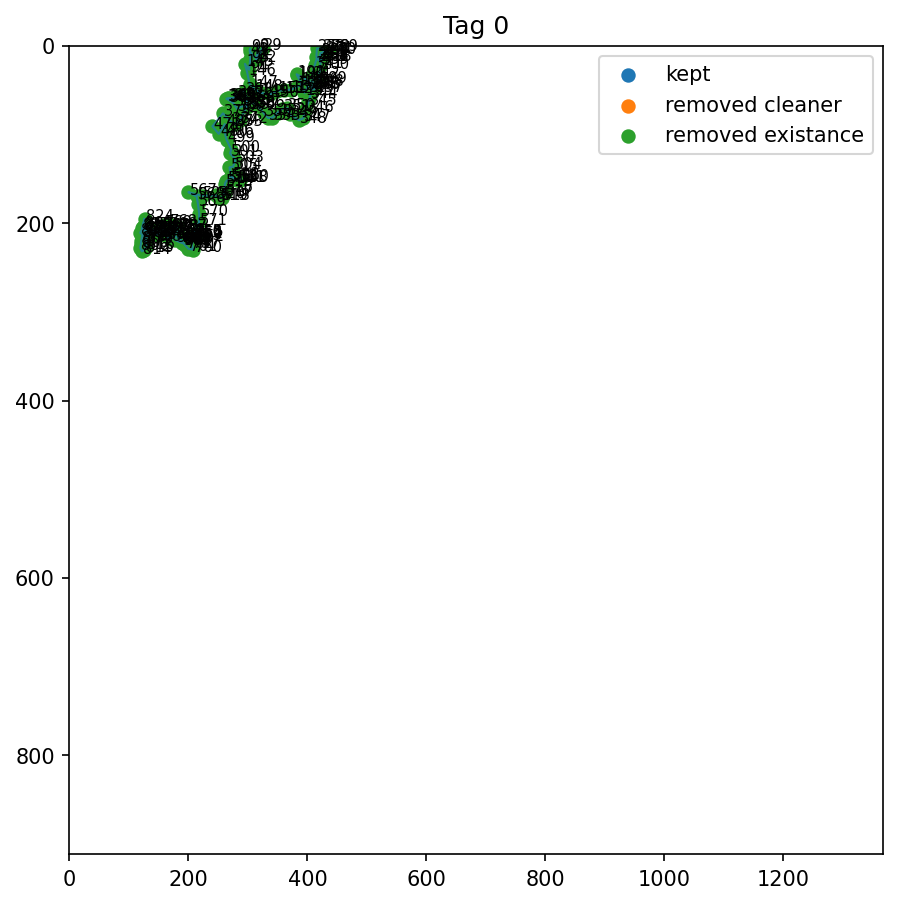

In [176]:
inspect_tag(0)

In [177]:
bad_tot = diag_tracks.loc[~diag_tracks["tot_disp_ok"], "tag"].tolist()

print("Numero traiettorie che falliscono tot_disp_ok:", len(bad_tot))
print("Primi tag:", bad_tot[:20])

Numero traiettorie che falliscono tot_disp_ok: 462
Primi tag: [28, 42, 50, 77, 110, 130, 146, 162, 202, 216, 237, 275, 336, 367, 406, 408, 417, 426, 436, 464]


,28
tag,28
n_raw,93
n_clean,93
blink_ok,False
life_ok,True
avg_step_ok,True
tot_disp_ok,False
exist_ok,False
clean_exist_ok,True
avg_step,9.828398


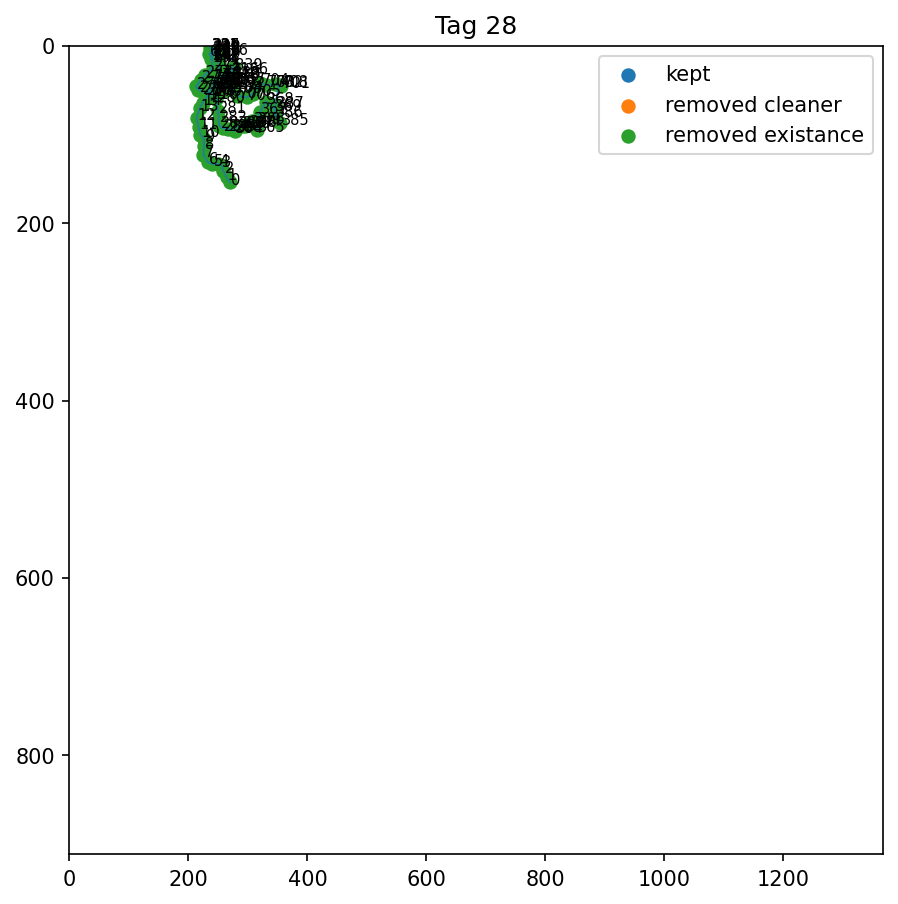

,42
tag,42
n_raw,158
n_clean,154
blink_ok,False
life_ok,True
avg_step_ok,True
tot_disp_ok,False
exist_ok,False
clean_exist_ok,True
avg_step,8.686745


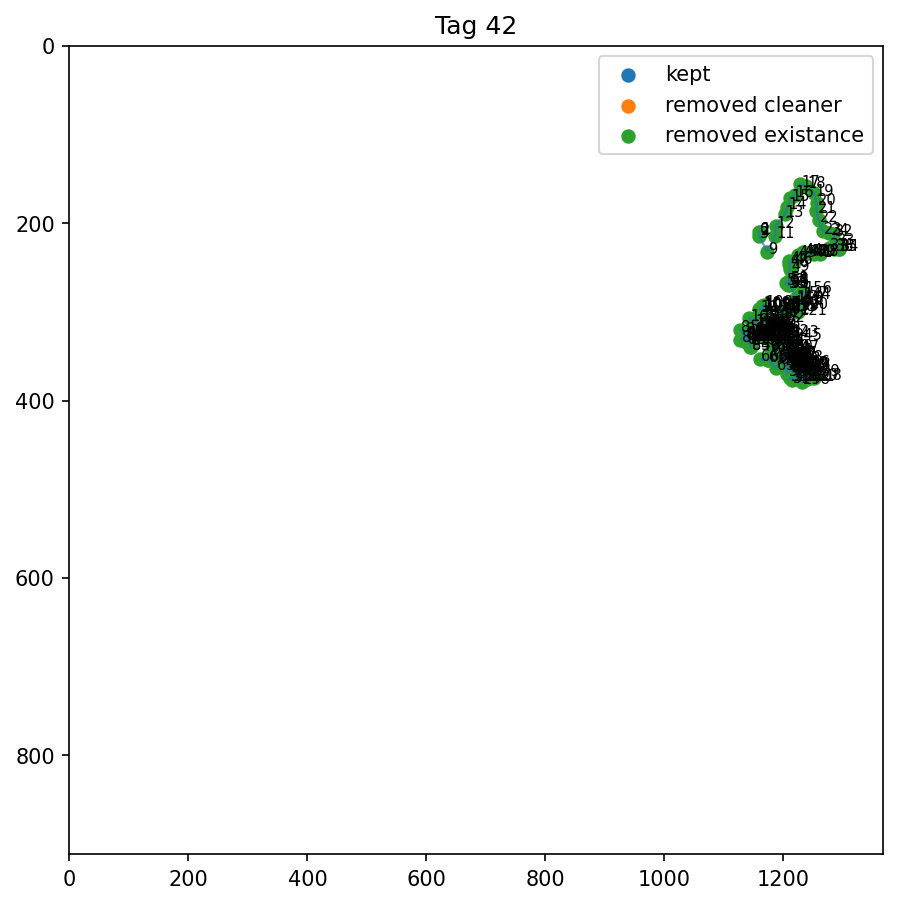

,50
tag,50
n_raw,150
n_clean,148
blink_ok,False
life_ok,True
avg_step_ok,True
tot_disp_ok,False
exist_ok,False
clean_exist_ok,True
avg_step,9.207795


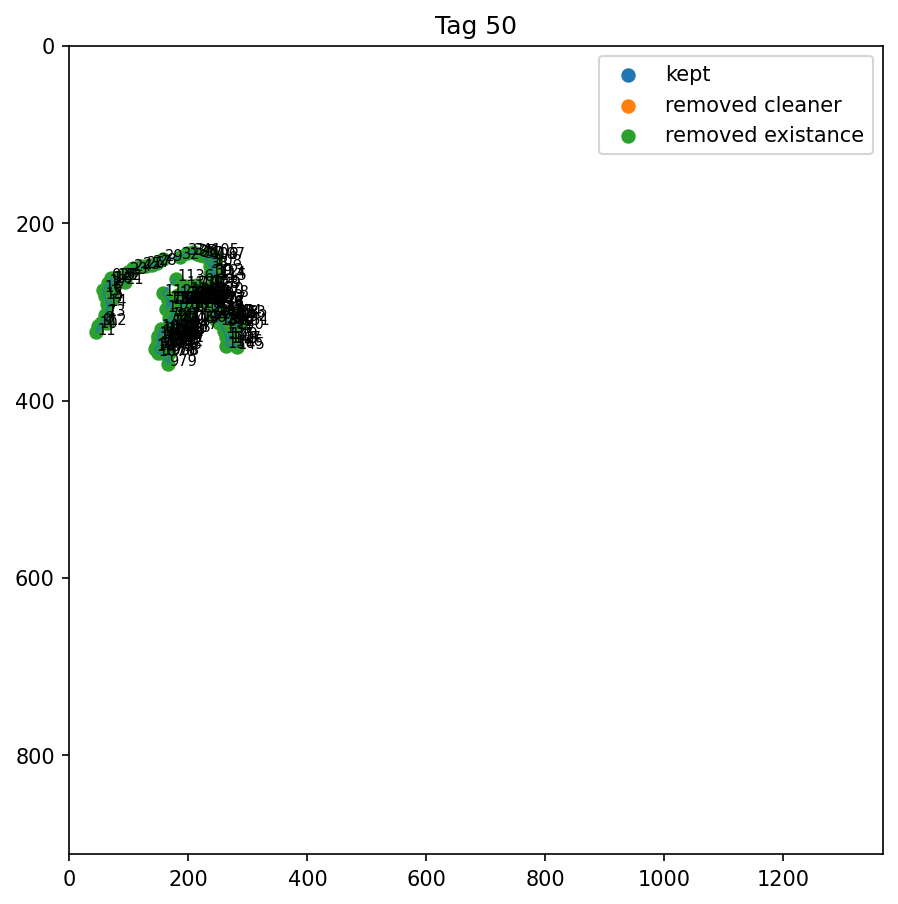

,77
tag,77
n_raw,408
n_clean,386
blink_ok,False
life_ok,True
avg_step_ok,True
tot_disp_ok,False
exist_ok,False
clean_exist_ok,True
avg_step,6.828806


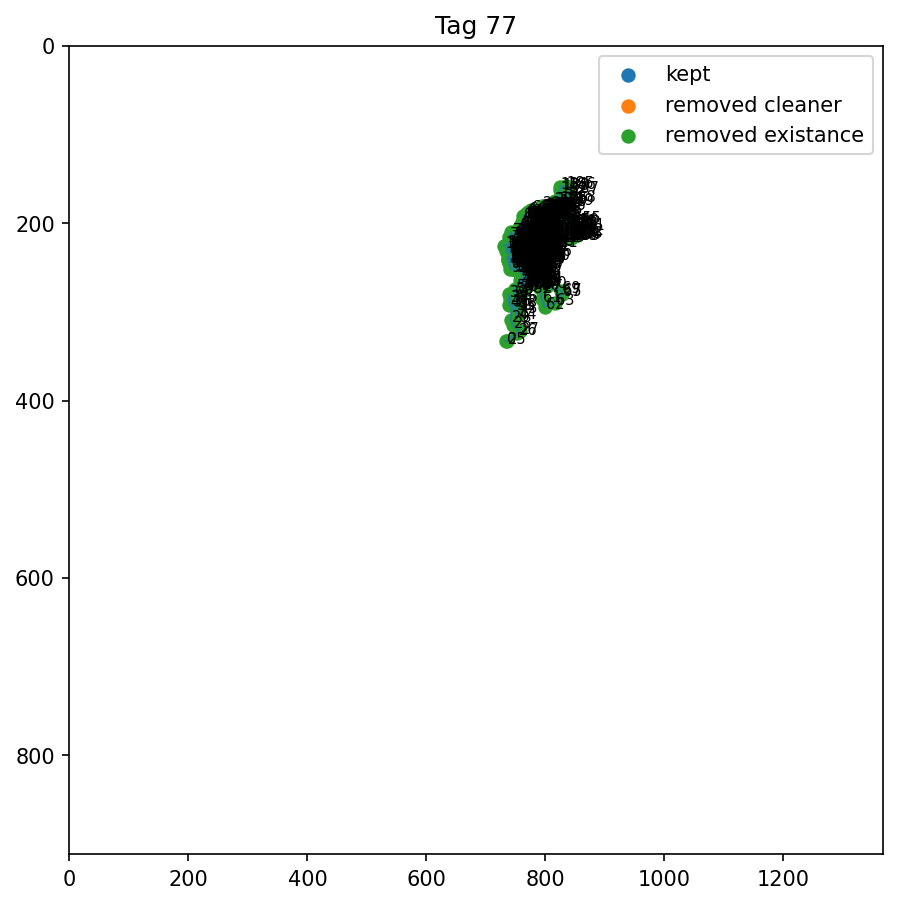

,110
tag,110
n_raw,253
n_clean,216
blink_ok,False
life_ok,True
avg_step_ok,True
tot_disp_ok,False
exist_ok,False
clean_exist_ok,True
avg_step,6.959823


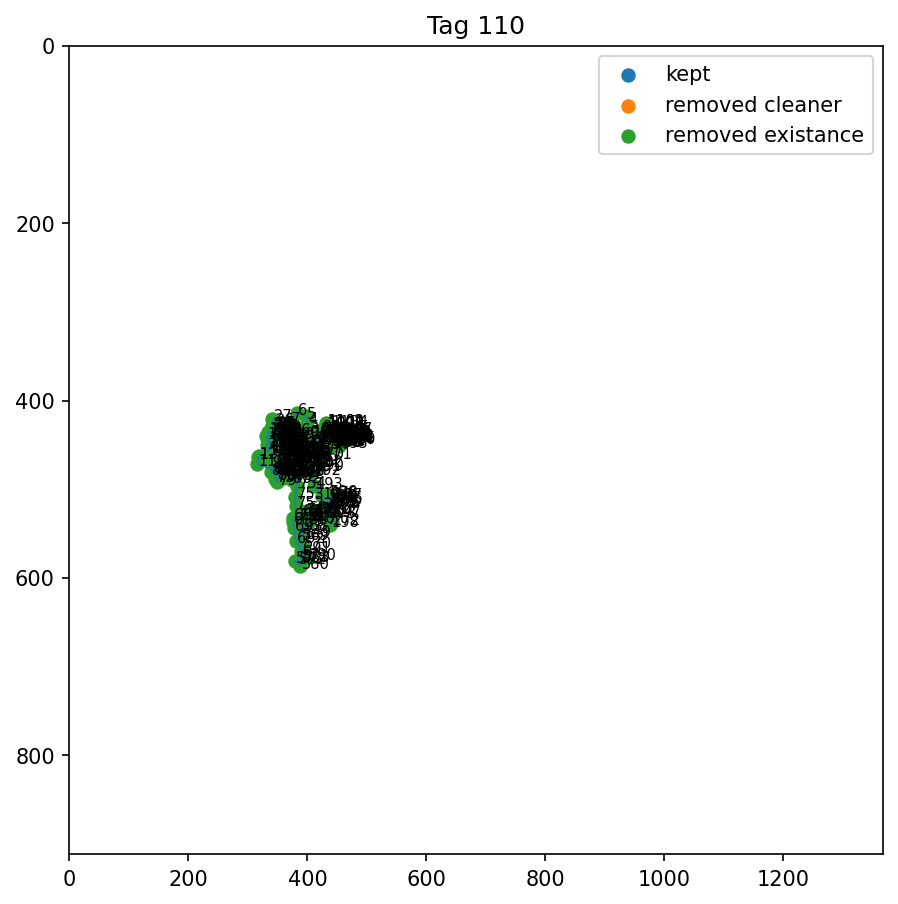

In [178]:
for tg in bad_tot[:5]:
    inspect_tag(tg)

In [179]:
def compute_existance_diag_euclid(snaps, xtraj, ytraj, dt, filt):
    snaps = np.asarray(snaps, dtype=int)
    xtraj = np.asarray(xtraj, dtype=float)
    ytraj = np.asarray(ytraj, dtype=float)

    n = len(snaps)
    if n == 0:
        return {
            "exist_ok": False,
            "disp_tot": np.nan
        }

    first_last_snap = snaps[-1] - snaps[0] + 1
    total_snaps = n

    if n >= 2:
        step = np.sqrt(np.diff(xtraj)**2 + np.diff(ytraj)**2)
        avg_step = np.mean(step)
        dx_tot = xtraj[-1] - xtraj[0]
        dy_tot = ytraj[-1] - ytraj[0]
        disp_tot = np.sqrt(dx_tot**2 + dy_tot**2)
    else:
        avg_step = 0.0
        disp_tot = 0.0

    blinking_cond = first_last_snap * filt["blinking_ratio"] < total_snaps
    minimum_lifetime_cond = total_snaps * dt > filt["lifetime_min"]
    minimum_avg_displ_cond = avg_step > filt["threshold_dist"]
    minimum_total_displ_cond = disp_tot > filt["threshold_dist_tot"]

    exist_ok = (
        blinking_cond
        and minimum_lifetime_cond
        and minimum_avg_displ_cond
        and minimum_total_displ_cond
    )

    return {
        "exist_ok": exist_ok,
        "disp_tot": disp_tot
    }

In [180]:
rows_compare = []

for tag, g in traj_df.sort_values(["tag", "snap"]).groupby("tag"):
    snaps = g["snap"].to_numpy(dtype=int)
    x = g["x_px"].to_numpy(dtype=float) * PIX
    y = g["y_px"].to_numpy(dtype=float) * PIX

    ex_old = compute_existance_diag(snaps, x, y, DT, FILT)
    ex_new = compute_existance_diag_euclid(snaps, x, y, DT, FILT)

    rows_compare.append({
        "tag": int(tag),
        "exist_original": ex_old["exist_ok"],
        "exist_euclid": ex_new["exist_ok"],
        "disp_tot": ex_new["disp_tot"]
    })

compare_exist = pd.DataFrame(rows_compare)

display(compare_exist.head())

rescued = ((~compare_exist["exist_original"]) & (compare_exist["exist_euclid"])).sum()
print("Traiettorie salvate dalla versione euclidea:", int(rescued))

,tag,exist_original,exist_euclid,disp_tot
0,0,False,False,259.660863
1,1,False,False,194.687473
2,2,False,False,117.456974
3,3,False,False,171.573806
4,4,False,False,77.606907


Traiettorie salvate dalla versione euclidea: 36
